In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

Multiprocessing: Below initialize julia on 7 cores

In [2]:
Main.eval('using Distributed')
Main.eval('addprocs(7)') 

array([2, 3, 4, 5, 6, 7, 8], dtype=int64)

In [3]:
Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")
Main.include("anomalous dim\\cusp\\cusp.jl")
Main.include("anomalous dim\\non-cusp\\gammaH.jl")
Main.include("anomalous dim\\non-cusp\\gammaB.jl")
Main.include("anomalous dim\\non-cusp\\gammaS.jl")
Main.include("anomalous dim\\non-cusp\\gammav.jl")
Main.include("anomalous dim\\non-cusp\\Integration.jl")
Main.include("hard\\hard.jl")
Main.include("jet\\jet.jl")
Main.include("soft\\soft.jl")
Main.include("sigma.jl")
Main.include("error.jl")
Main.include("fixed order\\perturbation.jl")
Main.include("fixed order\\SCET.jl")
Main.include("fixed order\\non-singular.jl")

<PyCall.jlwrap non_singular_sigma_χ>

In [9]:
χ_upper = 165
χ_lower = 115

dataset_qua = ["MAC"]  

df_qua = {}

for name in dataset_qua:
    file_path = f"data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = df["STAT"]
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_qua[name] = df1

dataset_ss = ["MARKII"]  

df_ss = {}

for name in dataset_ss:
    file_path = f"data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = np.sqrt(df["STAT"]**2+df["SYS"]**2)
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_ss[name] = df1

dataset_names = ["MAC", "MARKII"]    
df = df_qua
df.update(df_ss)

#---------------------------------------------------------------------------------

df_truncated = {}
χ = {}
EEC = {}
ERROR = {}

for name in dataset_names:
    df_truncated[name] = df[name][(df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]

    χ[name] = np.array(df_truncated[name]["CHI"])
    EEC[name] = np.array(df_truncated[name]["EEC"])
    ERROR[name] = np.array(df_truncated[name]["ERROR"])

Q = {}
Q["MAC"]=29.0
Q["MARKII"]=29.0

In [10]:
xlist = np.pi/180*np.linspace(χ_lower,χ_upper,num=50)

v_1 = Main.sigma_fast(Q=29.0, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="NLL'")
v_2 = Main.sigma_fast(Q=29.0, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="NNLL'")
v_3 = Main.sigma_fast(Q=29.0, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="N3LL'")
v_4 = Main.sigma_fast(Q=29.0, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="N4LL")

Close previous julias

In [125]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x000001f6b4fa47d0>

Non-singular

In [34]:
non_singular_91 = []
non_singular_29 = []
PERT=[]

for x in xlist:
    non_singular_91.append(Main.non_singular_sigma_χ(χ=x, Q=91.2, μ_ini=91.1876, αs_ini=0.118, nf=5, order=2))
    non_singular_29.append(Main.non_singular_sigma_χ(χ=x, Q=29.0, μ_ini=91.1876, αs_ini=0.118, nf=5, order=2))
    PERT.append(Main.perturbation_sigma_χ(χ=x, Q=29.0, μ_ini=91.1876, αs_ini=0.118, nf=5, order=2))

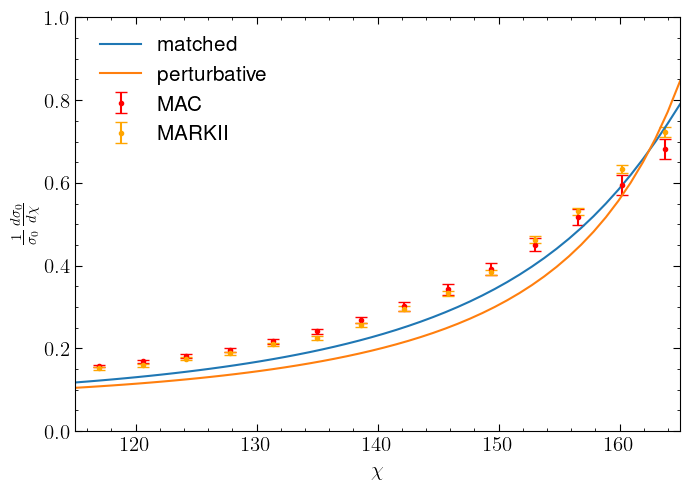

In [39]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5)) 

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","green","blue","black"]
i=0
for name in dataset_names:
    ax1.errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=name, color=color[i], capsize=4,markersize=3)
    i=i+1
ax1.plot(xlist*180/np.pi, v_3+non_singular_29, label="matched")
ax1.plot(xlist*180/np.pi, PERT, label="perturbative")


ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_0} \frac{d \sigma_0}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.35, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
#ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
#verticalalignment='top', bbox=props)

plt.ylim(0,1)
plt.xlim(χ_lower,χ_upper)

plt.tight_layout()  
plt.show()

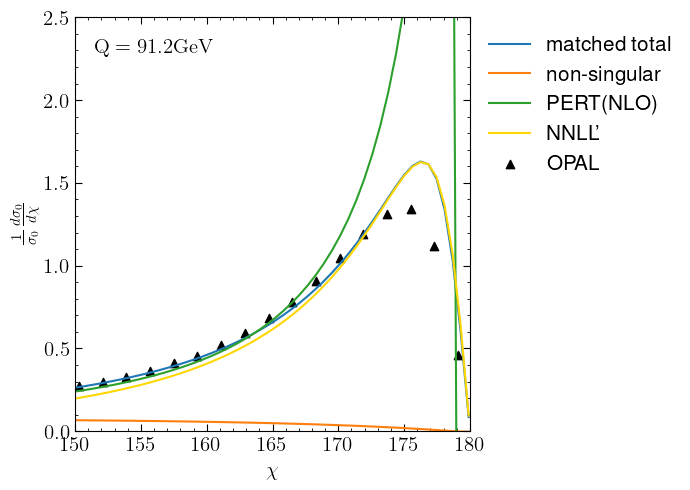

In [141]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5)) 

sizeOfFont = 15
sizeOfTick = 15

ax1.plot(xlist*180/np.pi, v_3+non_singular_2, label="matched total")
ax1.plot(xlist*180/np.pi, non_singular_2, label="non-singular")
#ax1.plot(xlist*180/np.pi, SCET_2, label="SCET")
#ax1.plot(xlist*180/np.pi, perturbation_1, label="PERT(LO)")
ax1.plot(xlist*180/np.pi, perturbation_2, label="PERT(NLO)")

#ax1.plot(xlist*180/np.pi, v_1, label="NLL'")
ax1.plot(xlist*180/np.pi, v_2, label="NNLL'",color="gold")
#ax1.plot(xlist*180/np.pi, v_3, label="N3LL'",color="red")
ax1.scatter(χ_list*180/np.pi, EEC, label="OPAL",marker="^",color="black")

ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_0} \frac{d \sigma_0}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(1, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
ax1.text(0.05, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
verticalalignment='top', bbox=props)

plt.ylim(0,2.5)
plt.xlim(150,180)

plt.tight_layout()  
plt.show()

In [108]:
EEC=np.array([0.272,0.299,0.329,0.365,0.410,0.457,0.521,0.595,0.682,0.783,0.906,1.049,1.19,1.31,1.34,1.12,0.46])
χ_list=np.pi*np.array([150.3,152.1,153.9,155.7,157.5,159.3,161.1,162.9,164.7,166.5,168.3,170.1,171.9,173.7,175.5,177.3,179.1])/180

xlist = np.pi/180*np.linspace(150,179.9,num=50)
length=len(xlist)

v_1 = Main.sigma_fast(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="NLL'")
v_2 = Main.sigma_fast(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="NNLL'")
v_3 = Main.sigma_fast(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="N3LL'")
v_4 = Main.sigma_fast(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="N4LL")

resum_error_1 = Main.resum_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="NLL'")
resum_error_2 = Main.resum_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="NNLL'")
resum_error_3 = Main.resum_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="N3LL'")
resum_error_4 = Main.resum_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="N4LL")

fixed_error_1 = Main.fixed_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="NLL'")
fixed_error_2 = Main.fixed_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="NNLL'")
fixed_error_3 = Main.fixed_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="N3LL'")
fixed_error_4 = Main.fixed_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="N4LL")

NP_error_1 = Main.NP_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="NLL'")
NP_error_2 = Main.NP_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="NNLL'")
NP_error_3 = Main.NP_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="N3LL'")
NP_error_4 = Main.NP_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, XLL="N4LL")

In [109]:
error_1 = np.sqrt(np.array(resum_error_1)**2+np.array(fixed_error_1)**2+np.array(NP_error_1)**2)
error_2 = np.sqrt(np.array(resum_error_2)**2+np.array(fixed_error_2)**2+np.array(NP_error_2)**2)
error_3 = np.sqrt(np.array(resum_error_3)**2+np.array(fixed_error_3)**2+np.array(NP_error_3)**2)
error_4 = np.sqrt(np.array(resum_error_4)**2+np.array(fixed_error_4)**2+np.array(NP_error_4)**2)

error_1_2 = np.sqrt(np.array(fixed_error_1)**2+np.array(NP_error_1)**2)
error_2_2 = np.sqrt(np.array(fixed_error_2)**2+np.array(NP_error_2)**2)
error_3_2 = np.sqrt(np.array(fixed_error_3)**2+np.array(NP_error_3)**2)
error_4_2 = np.sqrt(np.array(fixed_error_4)**2+np.array(NP_error_4)**2)

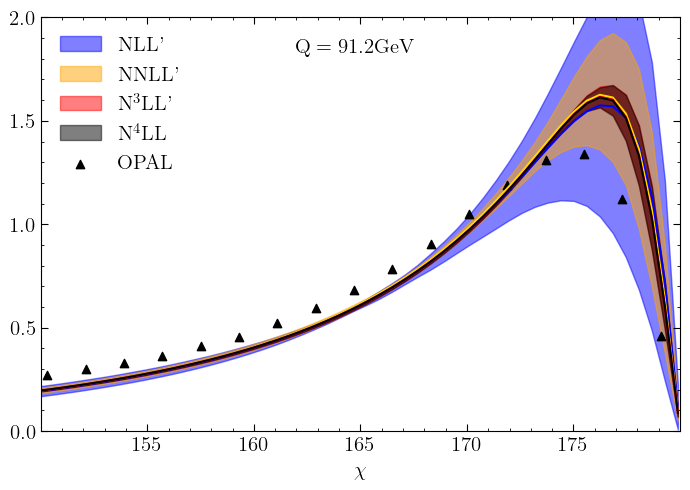

In [118]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5)) 

sizeOfFont = 15
sizeOfTick = 15

ax1.plot(xlist*180/np.pi, v_1, color="blue")
ax1.plot(xlist*180/np.pi, v_2, color="gold")
ax1.plot(xlist*180/np.pi, v_3, color="red")
ax1.plot(xlist*180/np.pi, v_4, color="black")

ax1.fill_between(xlist*180/np.pi, v_1 - error_1, v_1 + error_1, color="blue", alpha=0.5,label=r"\rm NLL'")
ax1.fill_between(xlist*180/np.pi, v_2 - error_2, v_2 + error_2, color="orange", alpha=0.5,label=r"\rm NNLL'")
ax1.fill_between(xlist*180/np.pi, v_3 - error_3, v_3 + error_3, color="red", alpha=0.5,label=r"\rm $\mathrm{N}^3$LL'")
ax1.fill_between(xlist*180/np.pi, v_4 - error_4, v_4 + error_4, color="black", alpha=0.5,label=r"\rm $\mathrm{N}^4$LL")

ax1.scatter(χ_list*180/np.pi, EEC, label=r"\rm OPAL",marker="^",color="black")
ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(1, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
verticalalignment='top', bbox=props)

ax1.legend(loc='upper left', frameon=False, fontsize=sizeOfFont)

plt.ylim(0,2)
plt.xlim(150,180)
plt.yticks([0, 0.5,1.0,1.5,2.0])
plt.xticks([155,160,165,170,175])

plt.tight_layout()  
plt.show()

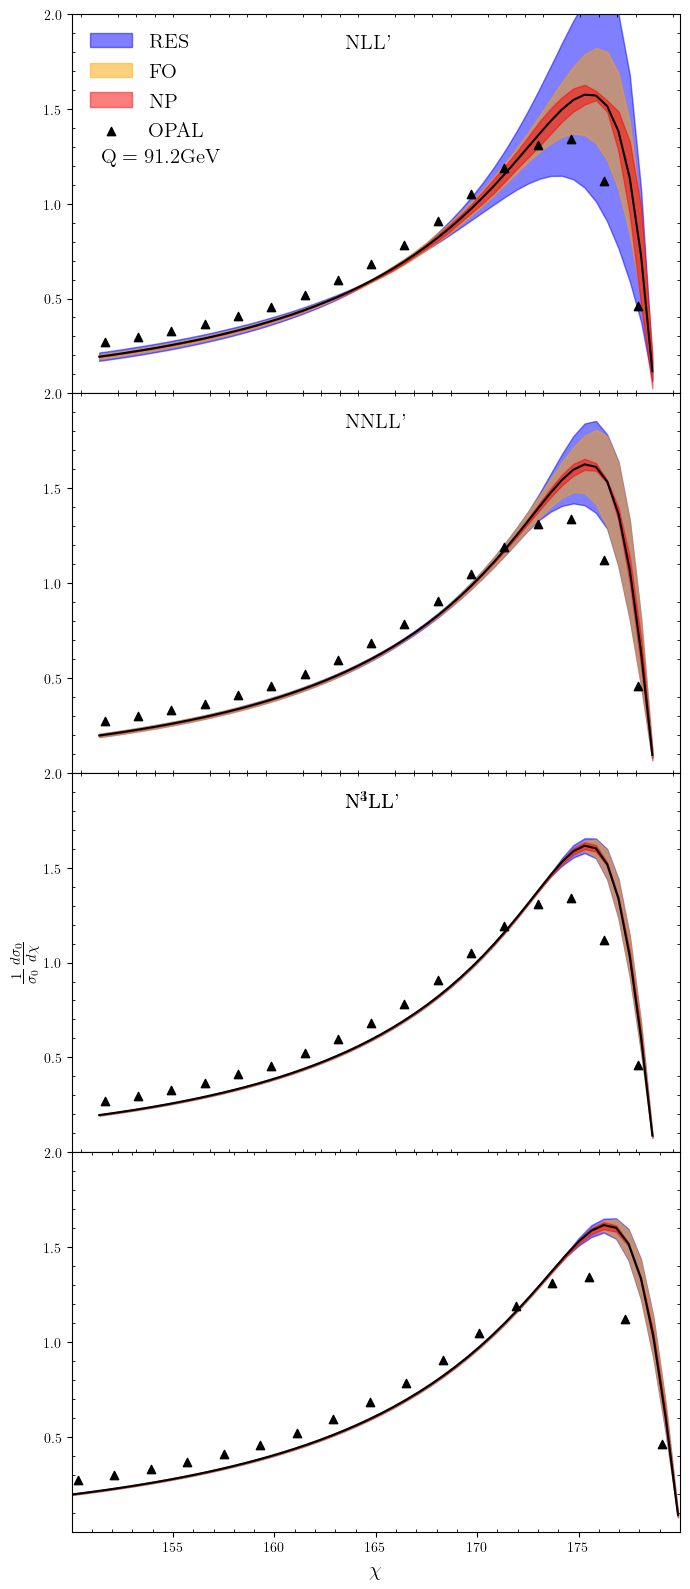

In [121]:
fig, [ax1,ax2,ax3,ax4] = plt.subplots(4, 1, figsize=(7, 16), sharey=True)

sizeOfFont = 15
sizeOfTick = 15

ax1.plot(xlist*180/np.pi, v_1, color="black")
ax1.fill_between(xlist*180/np.pi, v_1 - resum_error_1, v_1 + resum_error_1, color="blue", alpha=0.5, label=r"\rm RES")
ax1.fill_between(xlist*180/np.pi, v_1 - fixed_error_1, v_1 + fixed_error_1, color="orange", alpha=0.5, label=r"\rm FO")
ax1.fill_between(xlist*180/np.pi, v_1 - NP_error_1, v_1 + NP_error_1, color="red", alpha=0.5, label=r"\rm NP")

ax2.plot(xlist*180/np.pi, v_2, color="black")
ax2.fill_between(xlist*180/np.pi, v_2 - resum_error_2, v_2 + resum_error_2, color="blue", alpha=0.5)
ax2.fill_between(xlist*180/np.pi, v_2 - fixed_error_2, v_2 + fixed_error_2, color="orange", alpha=0.5)
ax2.fill_between(xlist*180/np.pi, v_2 - NP_error_2, v_2 + NP_error_2, color="red", alpha=0.5)

ax3.plot(xlist*180/np.pi, v_3, color="black")
ax3.fill_between(xlist*180/np.pi, v_3 - resum_error_3, v_3 + resum_error_3, color="blue", alpha=0.5)
ax3.fill_between(xlist*180/np.pi, v_3 - fixed_error_3, v_3 + fixed_error_3, color="orange", alpha=0.5)
ax3.fill_between(xlist*180/np.pi, v_3 - NP_error_3, v_3 + NP_error_3, color="red", alpha=0.5)

ax4.plot(xlist*180/np.pi, v_3, color="black")
ax4.fill_between(xlist*180/np.pi, v_4 - resum_error_4, v_4 + resum_error_4, color="blue", alpha=0.5)
ax4.fill_between(xlist*180/np.pi, v_4 - fixed_error_4, v_4 + fixed_error_4, color="orange", alpha=0.5)
ax4.fill_between(xlist*180/np.pi, v_4 - NP_error_4, v_4 + NP_error_4, color="red", alpha=0.5)

ax1.scatter(χ_list*180/np.pi, EEC, label=r"\rm OPAL",marker="^",color="black")
ax2.scatter(χ_list*180/np.pi, EEC, marker="^",color="black")
ax3.scatter(χ_list*180/np.pi, EEC, marker="^",color="black")
ax4.scatter(χ_list*180/np.pi, EEC, marker="^",color="black")

ax4.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax3.set_ylabel(r"\rm $\frac{1}{\sigma_0} \frac{d \sigma_0}{d \chi}$",fontsize=sizeOfFont)

ax1.minorticks_on()
ax2.minorticks_on()
ax3.minorticks_on()
ax4.minorticks_on()
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax2.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax3.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax4.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)

props = dict(boxstyle='round', facecolor='white', alpha=0)

ax1.text(0.45, 0.95,  r"\rm NLL'", transform=ax1.transAxes, fontsize=sizeOfFont,verticalalignment='top', bbox=props)
ax2.text(0.45, 0.95,  r"\rm NNLL'", transform=ax2.transAxes, fontsize=sizeOfFont,verticalalignment='top', bbox=props)
ax3.text(0.45, 0.95,  r"\rm $\mathrm{N}^3$LL'", transform=ax3.transAxes, fontsize=sizeOfFont,verticalalignment='top', bbox=props)
ax4.text(0.45, 0.95,  r"\rm $\mathrm{N}^4$LL", transform=ax3.transAxes, fontsize=sizeOfFont,verticalalignment='top', bbox=props)

ax1.text(0.05, 0.65,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
verticalalignment='top', bbox=props)

ax1.legend(loc='upper left', frameon=False, fontsize=sizeOfFont)

plt.ylim(0,2)
plt.xlim(150,180)
plt.yticks([0.5,1.0,1.5,2.0])
plt.xticks([155,160,165,170,175])

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

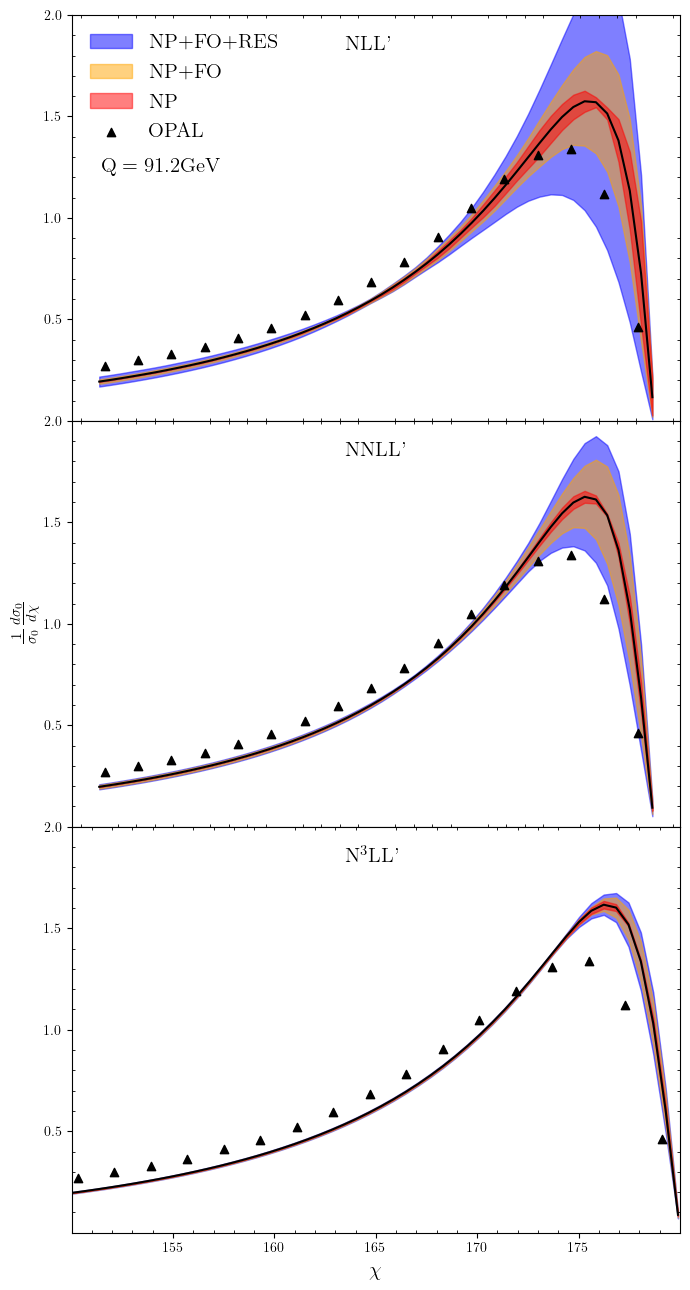

In [122]:
fig, [ax1,ax2,ax3] = plt.subplots(3, 1, figsize=(7, 13), sharey=True)

sizeOfFont = 15
sizeOfTick = 15

ax1.plot(xlist*180/np.pi, v_1, color="black")
ax1.fill_between(xlist*180/np.pi, v_1 - error_1, v_1 + error_1, color="blue", alpha=0.5, label=r"\rm NP+FO+RES")
ax1.fill_between(xlist*180/np.pi, v_1 - error_1_2, v_1 + error_1_2, color="orange", alpha=0.5, label=r"\rm NP+FO")
ax1.fill_between(xlist*180/np.pi, v_1 - NP_error_1, v_1 + NP_error_1, color="red", alpha=0.5, label=r"\rm NP")

ax2.plot(xlist*180/np.pi, v_2, color="black")
ax2.fill_between(xlist*180/np.pi, v_2 - error_2, v_2 + error_2, color="blue", alpha=0.5)
ax2.fill_between(xlist*180/np.pi, v_2 - error_2_2, v_2 + error_2_2, color="orange", alpha=0.5)
ax2.fill_between(xlist*180/np.pi, v_2 - NP_error_2, v_2 + NP_error_2, color="red", alpha=0.5)

ax3.plot(xlist*180/np.pi, v_3, color="black")
ax3.fill_between(xlist*180/np.pi, v_3 - error_3, v_3 + error_3, color="blue", alpha=0.5)
ax3.fill_between(xlist*180/np.pi, v_3 - error_3_2, v_3 + error_3_2, color="orange", alpha=0.5)
ax3.fill_between(xlist*180/np.pi, v_3 - NP_error_3, v_3 + NP_error_3, color="red", alpha=0.5)

ax1.scatter(χ_list*180/np.pi, EEC, label=r"\rm OPAL",marker="^",color="black")
ax2.scatter(χ_list*180/np.pi, EEC, marker="^",color="black")
ax3.scatter(χ_list*180/np.pi, EEC, marker="^",color="black")

ax3.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax2.set_ylabel(r"\rm $\frac{1}{\sigma_0} \frac{d \sigma_0}{d \chi}$",fontsize=sizeOfFont)

ax1.minorticks_on()
ax2.minorticks_on()
ax3.minorticks_on()
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax2.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax3.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)

props = dict(boxstyle='round', facecolor='white', alpha=0)

ax1.text(0.45, 0.95,  r"\rm NLL'", transform=ax1.transAxes, fontsize=sizeOfFont,verticalalignment='top', bbox=props)
ax2.text(0.45, 0.95,  r"\rm NNLL'", transform=ax2.transAxes, fontsize=sizeOfFont,verticalalignment='top', bbox=props)
ax3.text(0.45, 0.95,  r"\rm $\mathrm{N}^3$LL'", transform=ax3.transAxes, fontsize=sizeOfFont,verticalalignment='top', bbox=props)

ax1.text(0.05, 0.65,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
verticalalignment='top', bbox=props)

ax1.legend(loc='upper left', frameon=False, fontsize=sizeOfFont)

plt.ylim(0,2)
plt.xlim(150,180)
plt.yticks([0.5,1.0,1.5,2.0])
plt.xticks([155,160,165,170,175])

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

In [ ]:
blist = np.linspace(10000,1000000,num=1000)
length=len(blist)

v_1 =[]
v_2 =[]
v_3 =[]

for b in blist:
    #v_1.append(Main.integrated(Q=91.2, b=b, μ_ini=91.1876, αs_ini=0.118, nf=5, μ=91.1876, order=1))
    #v_2.append(Main.integrated(Q=91.2, b=b, μ_ini=91.1876, αs_ini=0.118, nf=5, μ=91.1876, order=2))
    v_3.append(Main.integrated(Q=91.2, b=b, μ_ini=91.1876, αs_ini=0.118, nf=5, μ=91.1876, order=3))

In [ ]:
blist = np.linspace(10000,1000000,num=1000)
length=len(blist)

v_1 =[]
v_2 =[]
v_3 =[]

for b in blist:
    #v_1.append(Main.integrated(Q=91.2, b=b, μ_ini=91.1876, αs_ini=0.118, nf=5, μ=91.1876, order=1))
    #v_2.append(Main.integrated(Q=91.2, b=b, μ_ini=91.1876, αs_ini=0.118, nf=5, μ=91.1876, order=2))
    v_3.append(Main.integrated(Q=91.2, b=b, μ_ini=91.1876, αs_ini=0.118, nf=5, μ=91.1876, order=3))

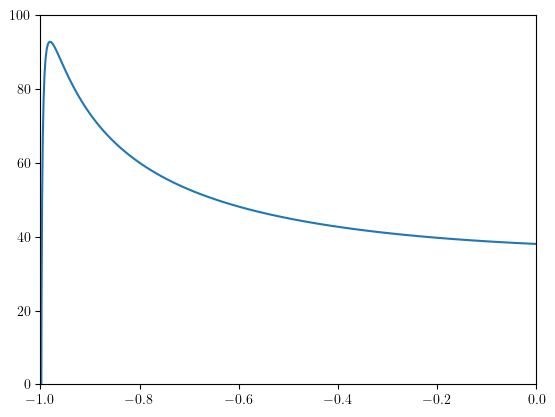

In [15]:
xlist = np.pi/180*np.linspace(90,179.9,num=100)
coslist = np.cos(xlist)

B = []

for x in xlist:
    z = 0.5*(1-np.cos(x))
    cosx = np.cos(x)
    sinx = np.sin(x)

    Blc = Main.Blc_func(z)
    Bnlc= Main.Bnlc_func(z)
    BNf = Main.Blc_func(z)
    B.append(sinx**2*(16/9*Blc+4/9*Bnlc+2*BNf)/4)

plt.ylim([0,100])
plt.xlim([-1,0])
plt.plot(coslist,B)